# AdaBoost — A Beginner-Friendly Learning Notebook

This notebook teaches **AdaBoost classification** through a complete project.

We will:

1. Understand AdaBoost in plain language.
2. Create separate **training, validation, and test** sets.
3. Train an `AdaBoostClassifier`.
4. Use validation performance to choose the number of boosting rounds.
5. Retrain the final model on training + validation data.
6. Evaluate once on the untouched test set.
7. Explain every model parameter used in simple language.
8. Inspect validation curves, predicted probabilities, and feature importance.
9. Save and reload the trained model.

The notebook uses the built-in scikit-learn breast-cancer dataset, so no dataset download is required.

## 1. What is AdaBoost?

**AdaBoost** means **Adaptive Boosting**.

The simple idea:

- Begin with a small decision tree.
- Find the rows it predicts incorrectly.
- Give those difficult rows more importance.
- Train another small tree that pays more attention to them.
- Combine all trees into one stronger model.

A useful mental model:

> **Learn → notice mistakes → focus more on mistakes → combine many learners**

AdaBoost usually uses very small trees called **decision stumps**. A stump is commonly a tree with only one split.

## 2. Why use training, validation, and test sets?

| Dataset | Used for | Simple meaning |
|---|---|---|
| **Training set** | Fit the boosting model | The model studies this data. |
| **Validation set** | Choose the number of boosting rounds and compare settings | A practice exam. |
| **Test set** | One final unbiased evaluation | The final exam. |

We use approximately:

- **70% training**
- **15% validation**
- **15% test**

The test set stays untouched until the final model is ready.

> AdaBoost in scikit-learn does not provide native validation-set early stopping. We imitate the same idea by measuring validation performance after each boosting stage and selecting the best stage.

## 3. Install packages

Run this cell only when the packages are missing. In Google Colab, remove the `#` before `%pip`.

In [1]:
# %pip install -q scikit-learn pandas numpy matplotlib joblib

## 4. Imports and reproducibility

In [2]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print('scikit-learn version:', sklearn.__version__)

scikit-learn version: 1.8.0


### Why `random_state=42`?

Random operations can produce slightly different results each time. A fixed seed makes the notebook repeatable. The number `42` is not special; any fixed integer can be used.

## 5. Load the dataset

In [3]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()
class_names = list(data.target_names)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', dict(enumerate(class_names)))
X.head()

Feature matrix shape: (569, 30)
Target shape: (569,)
Classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Important terms

- **Row / sample:** One patient record.
- **Feature:** One input measurement used by the model.
- **Target / label:** The answer the model predicts.
- **Weak learner:** A small model that is only moderately useful by itself.
- **Sample weight:** A number telling AdaBoost how much attention to give a row.
- **Boosting stage:** One additional weak learner added to the ensemble.

In [4]:
summary = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'missing_values': X.isna().sum(),
    'minimum': X.min(),
    'maximum': X.max(),
    'mean': X.mean(),
})

print('Missing values:', int(X.isna().sum().sum()))
print('\nClass counts:')
print(y.value_counts().rename(index={0: class_names[0], 1: class_names[1]}))
summary.head(10)

Missing values: 0

Class counts:
target
benign       357
malignant    212
Name: count, dtype: int64


,dtype,missing_values,minimum,maximum,mean
mean radius,float64,0,6.98100,28.11000,14.127292
mean texture,float64,0,9.71000,39.28000,19.289649
mean perimeter,float64,0,43.79000,188.50000,91.969033
mean area,float64,0,143.50000,2501.00000,654.889104
mean smoothness,float64,0,0.05263,0.16340,0.096360
mean compactness,float64,0,0.01938,0.34540,0.104341
mean concavity,float64,0,0.00000,0.42680,0.088799
mean concave points,float64,0,0.00000,0.20120,0.048919
mean symmetry,float64,0,0.10600,0.30400,0.181162
mean fractal dimension,float64,0,0.04996,0.09744,0.062798


## 6. Split into training, validation, and test sets

In [5]:
# First keep 30% aside. It will later become 15% validation + 15% test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Divide the temporary set equally.
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    'rows': [len(X_train), len(X_validation), len(X_test)],
    'percentage': [
        len(X_train) / len(X),
        len(X_validation) / len(X),
        len(X_test) / len(X),
    ],
    'positive_class_rate': [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=['Training', 'Validation', 'Test'])

split_summary.style.format({'percentage': '{:.1%}', 'positive_class_rate': '{:.1%}'})

,rows,percentage,positive_class_rate
Training,398,69.9%,62.8%
Validation,85,14.9%,62.4%
Test,86,15.1%,62.8%


### Parameters used in `train_test_split`

| Parameter | Simple meaning |
|---|---|
| `test_size=0.30` | Keep 30% of the rows aside in the first split. |
| `test_size=0.50` | Divide the temporary 30% into two equal parts. |
| `stratify=y` | Keep approximately the same class ratio in every split. |
| `random_state=42` | Make the random split repeatable. |

## 7. Parameters used in our AdaBoost model

### Base decision tree parameters

| Parameter | Value | Simple meaning |
|---|---:|---|
| `max_depth` | `1` | The tree can make only one split. This creates a decision stump. |
| `min_samples_leaf` | `5` | Every final branch must contain at least five training rows. |
| `random_state` | `42` | Makes random behavior repeatable. |

### AdaBoost parameters

| Parameter | Value | Simple meaning |
|---|---:|---|
| `estimator` | decision stump | The small model AdaBoost repeatedly trains. |
| `n_estimators` | `400` | Maximum number of boosting stages to inspect. |
| `learning_rate` | `0.05` | Shrinks the influence of each new learner. Smaller values learn more cautiously. |
| `random_state` | `42` | Makes the training process repeatable. |

The `algorithm` parameter is intentionally not used. Modern scikit-learn versions use the supported AdaBoost classification algorithm directly.

## 8. Create and train a large candidate model

In [6]:
base_tree = DecisionTreeClassifier(
    max_depth=1,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)

candidate_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=400,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)

candidate_model.fit(X_train, y_train)
print('Candidate model trained with', len(candidate_model.estimators_), 'boosting stages.')

Candidate model trained with 400 boosting stages.


## 9. Select the best boosting stage with validation data

`staged_predict_proba()` returns predictions after stage 1, stage 2, stage 3, and so on.

We calculate validation log loss after every stage. The stage with the **lowest validation log loss** is selected.

This performs the role of manual early stopping:

1. Train many possible stages on the training set.
2. Check the validation set after every stage.
3. Keep the stage that generalizes best.
4. Never inspect the test set during this choice.

In [7]:
validation_log_losses = []
validation_auc_scores = []

for probabilities in candidate_model.staged_predict_proba(X_validation):
    positive_probabilities = probabilities[:, 1]
    validation_log_losses.append(log_loss(y_validation, positive_probabilities))
    validation_auc_scores.append(roc_auc_score(y_validation, positive_probabilities))

best_stage = int(np.argmin(validation_log_losses) + 1)
best_validation_loss = validation_log_losses[best_stage - 1]
best_validation_auc = validation_auc_scores[best_stage - 1]

print('Best boosting stage:', best_stage)
print('Validation log loss at best stage:', round(best_validation_loss, 4))
print('Validation ROC AUC at best stage:', round(best_validation_auc, 4))

Best boosting stage: 9
Validation log loss at best stage: 0.1924
Validation ROC AUC at best stage: 0.9965


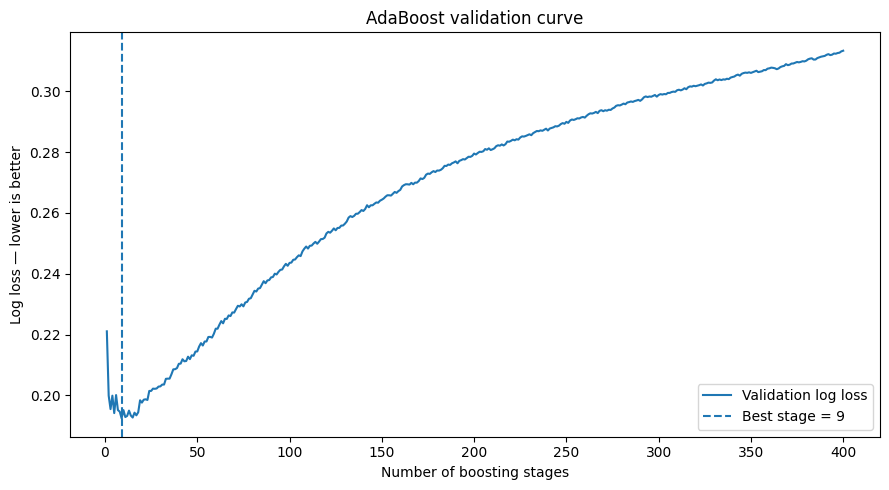

In [8]:
rounds = np.arange(1, len(validation_log_losses) + 1)

plt.figure(figsize=(9, 5))
plt.plot(rounds, validation_log_losses, label='Validation log loss')
plt.axvline(best_stage, linestyle='--', label=f'Best stage = {best_stage}')
plt.xlabel('Number of boosting stages')
plt.ylabel('Log loss — lower is better')
plt.title('AdaBoost validation curve')
plt.legend()
plt.tight_layout()
plt.show()

### Reading the validation curve

- Falling validation loss means additional learners are helping.
- A flat curve means additional learners provide little improvement.
- Rising validation loss can indicate overfitting.
- The dashed line marks the number of stages chosen without using the test set.

## 10. Train the selected validation model

In [9]:
validation_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    n_estimators=best_stage,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)

validation_model.fit(X_train, y_train)
print('Selected validation model trained.')

Selected validation model trained.


## 11. A reusable evaluation function

In [10]:
def evaluate_classifier(model, X_eval, y_eval, set_name='Dataset'):
    """Print useful binary-classification metrics and draw two diagnostic plots."""
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    metrics = pd.Series({
        'Accuracy': accuracy_score(y_eval, predictions),
        'Precision': precision_score(y_eval, predictions, zero_division=0),
        'Recall': recall_score(y_eval, predictions, zero_division=0),
        'F1 score': f1_score(y_eval, predictions, zero_division=0),
        'ROC AUC': roc_auc_score(y_eval, probabilities),
        'Log loss': log_loss(y_eval, probabilities),
    }, name=set_name)

    display(metrics.to_frame().round(4))
    print(classification_report(
        y_eval,
        predictions,
        target_names=class_names,
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        display_labels=class_names,
    )
    plt.title(f'{set_name}: confusion matrix')
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_predictions(y_eval, probabilities)
    plt.title(f'{set_name}: ROC curve')
    plt.tight_layout()
    plt.show()

    return metrics

### Metric meanings

| Metric | Simple meaning |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct. |
| **Precision** | When the model predicts class 1, how often is it correct? |
| **Recall** | Of all real class-1 rows, how many did the model find? |
| **F1 score** | A balance between precision and recall. |
| **ROC AUC** | How well the model ranks class 1 above class 0 across thresholds. |
| **Log loss** | Measures probability quality and strongly penalizes confident mistakes. Lower is better. |

## 12. Evaluate on the validation set

,Validation set
Accuracy,0.9647
Precision,1.0000
Recall,0.9434
F1 score,0.9709
ROC AUC,0.9965
Log loss,0.1924


              precision    recall  f1-score   support

   malignant       0.91      1.00      0.96        32
      benign       1.00      0.94      0.97        53

    accuracy                           0.96        85
   macro avg       0.96      0.97      0.96        85
weighted avg       0.97      0.96      0.96        85



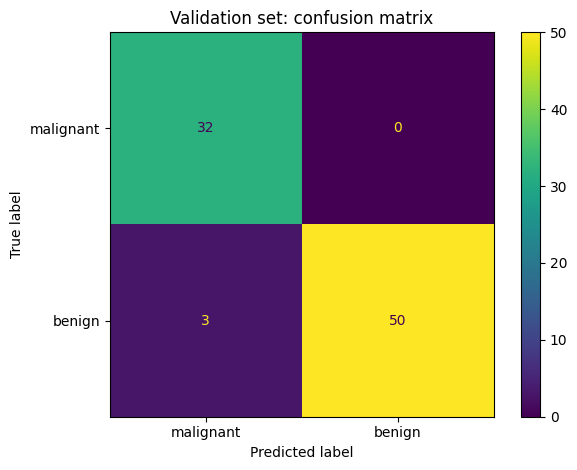

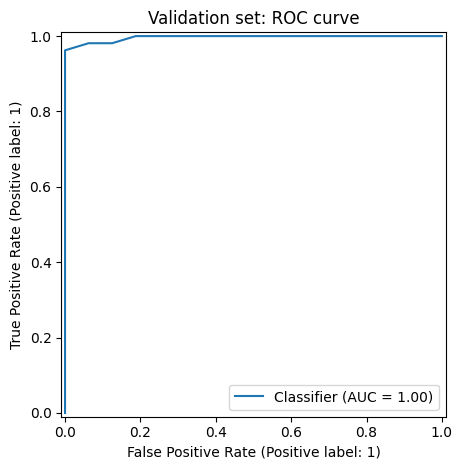

In [11]:
validation_metrics = evaluate_classifier(
    validation_model,
    X_validation,
    y_validation,
    set_name='Validation set',
)

## 13. Retrain on training + validation data

The validation set has completed its job: it selected `best_stage`.

We now combine training and validation rows and train a fresh AdaBoost model using exactly that number of stages. The test set remains untouched.

In [12]:
X_development = pd.concat([X_train, X_validation], axis=0)
y_development = pd.concat([y_train, y_validation], axis=0)

final_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    n_estimators=best_stage,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)

final_model.fit(X_development, y_development)
print('Final model training rows:', len(X_development))
print('Final number of boosting stages:', len(final_model.estimators_))

Final model training rows: 483
Final number of boosting stages: 9


## 14. Final evaluation on the untouched test set

,Untouched test set
Accuracy,0.8837
Precision,0.8929
Recall,0.9259
F1 score,0.9091
ROC AUC,0.9456
Log loss,0.3079


              precision    recall  f1-score   support

   malignant       0.87      0.81      0.84        32
      benign       0.89      0.93      0.91        54

    accuracy                           0.88        86
   macro avg       0.88      0.87      0.87        86
weighted avg       0.88      0.88      0.88        86



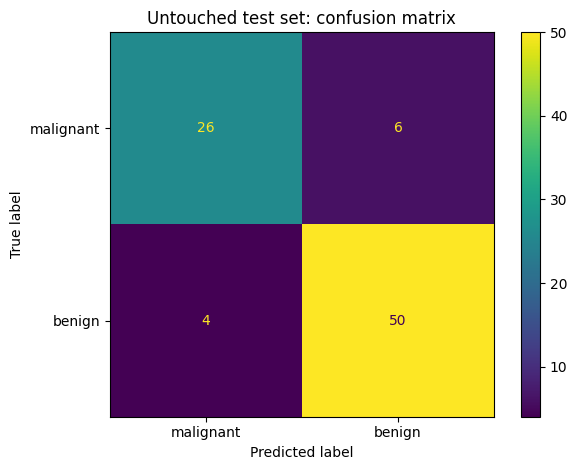

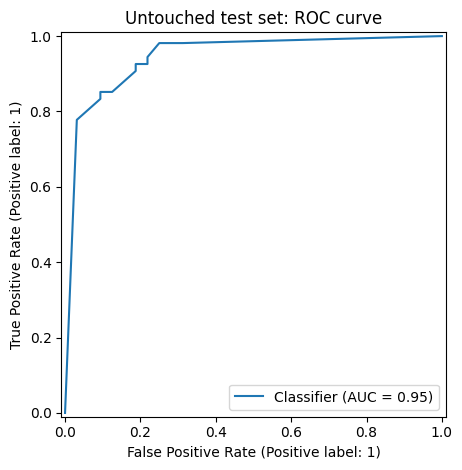

In [13]:
test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test,
    set_name='Untouched test set',
)

Treat these test metrics as the final estimate for this model-development cycle. Repeatedly changing the model after seeing test results slowly turns the test set into another validation set.

## 15. Inspect predicted probabilities

In [14]:
probability_examples = X_test.head(10).copy()
probability_examples['actual_class'] = y_test.head(10).map(dict(enumerate(class_names)))
probability_examples['predicted_class'] = pd.Series(
    final_model.predict(X_test.head(10)),
    index=X_test.head(10).index,
).map(dict(enumerate(class_names)))
probability_examples['probability_of_class_1'] = final_model.predict_proba(X_test.head(10))[:, 1]

probability_examples[['actual_class', 'predicted_class', 'probability_of_class_1']].round(4)

,actual_class,predicted_class,probability_of_class_1
102,benign,benign,0.8808
17,malignant,malignant,0.1192
370,malignant,malignant,0.1192
564,malignant,malignant,0.1192
38,malignant,benign,0.8808
204,benign,benign,0.8808
73,malignant,benign,0.7497
51,benign,benign,0.8808
363,benign,malignant,0.4346
41,malignant,benign,0.7571


A probability near `1.0` means the model strongly favors class 1. A probability near `0.0` means it strongly favors class 0. The default class decision normally uses a threshold of `0.5`.

## 16. Feature importance

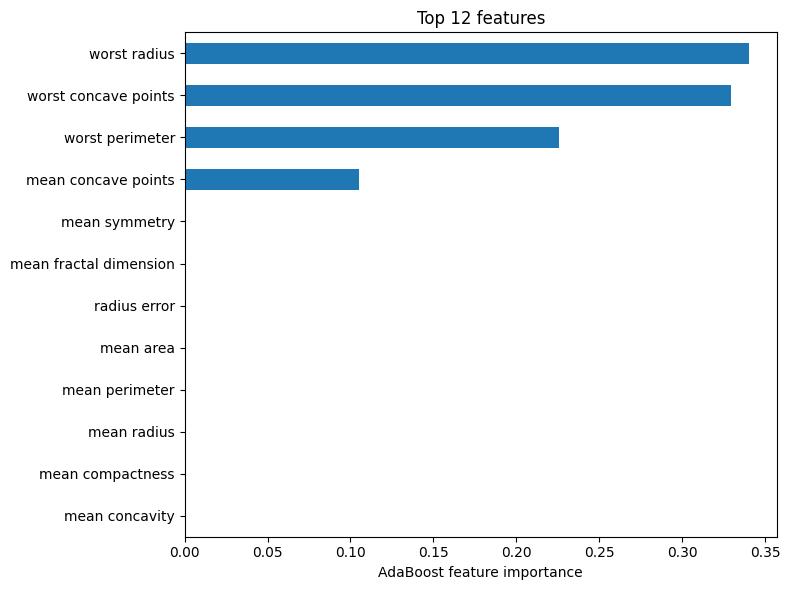

,importance
worst radius,0.340041
worst concave points,0.329266
worst perimeter,0.225757
mean concave points,0.104937
mean perimeter,0.000000
mean radius,0.000000
mean compactness,0.000000
mean concavity,0.000000
mean symmetry,0.000000
mean fractal dimension,0.000000


In [15]:
feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns,
    name='importance',
).sort_values(ascending=False)

feature_importance.head(12).sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('AdaBoost feature importance')
plt.title('Top 12 features')
plt.tight_layout()
plt.show()

feature_importance.head(12).to_frame()

Feature importance reports how much the fitted ensemble relied on each feature. It does **not** prove that a feature causes the target, and correlated features can share or distort importance.

## 17. Common AdaBoost parameters — simple reference

| Parameter | Simple meaning | Common effect |
|---|---|---|
| `estimator` | The weak model trained repeatedly | More complex estimators can learn richer patterns but may overfit. |
| `n_estimators` | Number of boosting stages | More stages can improve fit but increase time and overfitting risk. |
| `learning_rate` | Contribution of every new estimator | Smaller values usually require more estimators. |
| `random_state` | Random seed | Makes results reproducible. |

### Common base-tree parameters

| Parameter | Simple meaning |
|---|---|
| `max_depth` | Maximum number of split levels in each tree. |
| `min_samples_split` | Minimum rows required before a node may split. |
| `min_samples_leaf` | Minimum rows required in a final leaf. |
| `max_features` | Number of features considered when searching for a split. |
| `class_weight` | Gives selected classes more importance inside the base tree. |

## 18. Optional small parameter search

In [16]:
# This search uses only training + validation data. The test set remains untouched.
# It is intentionally small so the logic is easy to understand.

search_results = []
parameter_grid = {
    'max_depth': [1, 2],
    'min_samples_leaf': [1, 5, 10],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.03, 0.1, 0.5],
}

for params in ParameterGrid(parameter_grid):
    trial = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=RANDOM_STATE,
        ),
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        random_state=RANDOM_STATE,
    )
    trial.fit(X_train, y_train)
    validation_probability = trial.predict_proba(X_validation)[:, 1]
    search_results.append({
        **params,
        'validation_log_loss': log_loss(y_validation, validation_probability),
        'validation_roc_auc': roc_auc_score(y_validation, validation_probability),
    })

search_table = pd.DataFrame(search_results).sort_values(
    ['validation_log_loss', 'validation_roc_auc'],
    ascending=[True, False],
)
search_table.head(10)

,learning_rate,max_depth,min_samples_leaf,n_estimators,validation_log_loss,validation_roc_auc
15,0.03,2,10,50,0.179561,1.000000
12,0.03,2,5,50,0.182067,1.000000
9,0.03,2,1,50,0.186202,1.000000
16,0.03,2,10,100,0.198251,1.000000
13,0.03,2,5,100,0.201132,1.000000
0,0.03,1,1,50,0.203461,0.996167
3,0.03,1,5,50,0.203461,0.996167
6,0.03,1,10,50,0.203461,0.996167
10,0.03,2,1,100,0.203484,1.000000
30,0.10,2,5,50,0.219070,1.000000


The search above is educational. For serious projects, use cross-validation on the development data and choose the scoring metric that matches the business objective.

## 19. Save and reload the model

In [17]:
model_path = Path('adaboost_breast_cancer_model.joblib')
joblib.dump(final_model, model_path)

reloaded_model = joblib.load(model_path)
original_predictions = final_model.predict(X_test)
reloaded_predictions = reloaded_model.predict(X_test)

print('Saved to:', model_path.resolve())
print('Reloaded predictions are identical:', np.array_equal(original_predictions, reloaded_predictions))

Saved to: /mnt/data/adaboost_breast_cancer_model.joblib
Reloaded predictions are identical: True


## 20. Practical tuning guide

| Situation | First parameters to try |
|---|---|
| Training underfits | Increase `n_estimators`, increase base-tree depth slightly, or increase `learning_rate` carefully. |
| Validation performance gets worse | Reduce tree depth, increase `min_samples_leaf`, lower `learning_rate`, or select fewer stages. |
| Training is slow | Reduce `n_estimators` or simplify the base estimator. |
| Labels contain noise | Use simpler base trees and avoid very aggressive learning rates. |
| Class 1 is rare | Focus on precision/recall metrics and consider a base estimator with `class_weight`. |

Change one or two related parameters at a time. Record validation results instead of tuning from memory.

## 21. Common mistakes

1. **Using the test set to choose `n_estimators`.** Use validation data instead.
2. **Using deep base trees immediately.** AdaBoost is commonly strongest with simple learners.
3. **Judging only by accuracy.** Check recall, precision, AUC, and the confusion matrix.
4. **Ignoring noisy labels.** AdaBoost repeatedly emphasizes difficult rows, including mislabeled rows.
5. **Treating feature importance as causality.** Importance describes model usage, not real-world cause.
6. **Forgetting reproducibility.** Set random seeds when comparing experiments.

## 22. Exercises

1. Change `learning_rate` from `0.05` to `0.5`. What happens to the best stage?
2. Change the base tree from `max_depth=1` to `max_depth=2`.
3. Optimize validation ROC AUC instead of validation log loss.
4. Compare AdaBoost with a single decision tree.
5. Create an imbalanced version of the target and inspect precision versus recall.
6. Replace the dataset with your own CSV file using the template below.

## 23. Template for your own CSV dataset

In [18]:
# Example template — edit the file path and target column.
#
# df = pd.read_csv('your_data.csv')
# target_column = 'target'
#
# X = df.drop(columns=[target_column])
# y = df[target_column]
#
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=0.30,
#     stratify=y,
#     random_state=RANDOM_STATE,
# )
# X_validation, X_test, y_validation, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     stratify=y_temp,
#     random_state=RANDOM_STATE,
# )
#
# Important: AdaBoost's base decision tree requires numeric input.
# Encode text categories with a preprocessing pipeline fitted on training data only.

## 24. Final checklist

- [x] Separate training, validation, and test sets
- [x] Stratified splitting
- [x] Every used model parameter explained
- [x] Manual validation-based stage selection
- [x] Final retraining on training + validation data
- [x] Test set evaluated once
- [x] Multiple classification metrics
- [x] Validation curve
- [x] Feature importance
- [x] Optional parameter search
- [x] Model saving and reloading

### Official documentation

- [scikit-learn AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)
- [scikit-learn ensemble user guide](https://scikit-learn.org/stable/modules/ensemble.html#adaboost)